# Assignment 1 — Pokemon Type Classification
## Task 1: Multilayer Perceptron (MLP)

**Evaluation metric:** Macro-averaged F1 Score
**Goal:** Predict the primary type of each Pokemon from its image

In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from tqdm.auto import tqdm

In [3]:
# Paths
BASE_DIR   = os.path.join(os.path.dirname(os.getcwd()), "data") if "notebooks" in os.getcwd() else "data"
TRAIN_DIR  = os.path.join(BASE_DIR, "Train")
TEST_DIR   = os.path.join(BASE_DIR, "Test")
LABELS_CSV = os.path.join(BASE_DIR, "train_labels.csv")
CKPT_PATH  = "best_mlp.pth"

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Train dir : {TRAIN_DIR}")
print(f"Test dir  : {TEST_DIR}")
print(f"Labels CSV: {LABELS_CSV}")

Device: cuda
Train dir : C:\Projects\DeepLearning\Assignment1\data\Train
Test dir  : C:\Projects\DeepLearning\Assignment1\data\Test
Labels CSV: C:\Projects\DeepLearning\Assignment1\data\train_labels.csv


## 1. Data Exploration

Total training samples: 3600

Columns: ['Id', 'label']

Unique classes (9):
['Bug', 'Fighting', 'Fire', 'Grass', 'Ground', 'Normal', 'Poison', 'Rock', 'Water']

Class distribution:
label
Bug         374
Fighting    291
Fire        381
Grass       299
Ground      244
Normal      606
Poison      467
Rock        264
Water       674


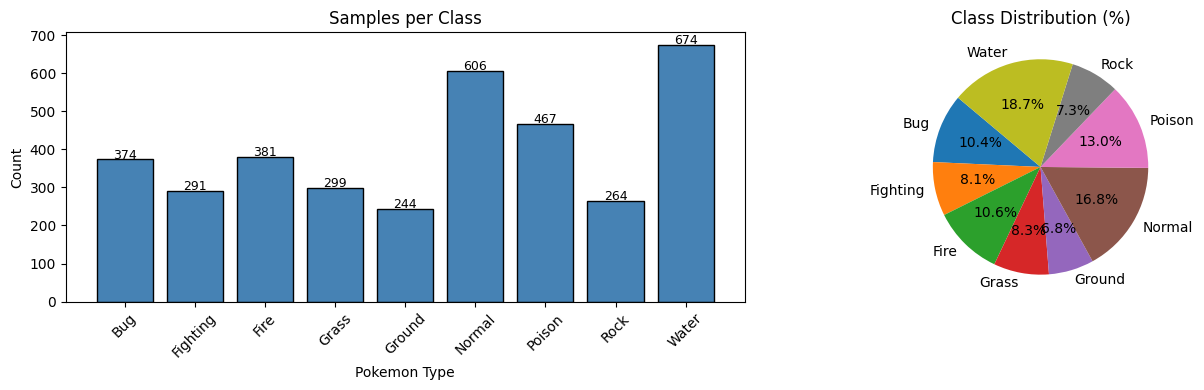


Most frequent class : Water (674 samples)
Least frequent class: Ground (244 samples)
Imbalance ratio     : 2.8x


In [4]:
# Load labels
df = pd.read_csv(LABELS_CSV)
print(f"Total training samples: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nUnique classes ({df['label'].nunique()}):")
print(sorted(df['label'].unique()))

# Class distribution
class_counts = df['label'].value_counts().sort_index()
print(f"\nClass distribution:")
print(class_counts.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart
axes[0].bar(class_counts.index, class_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title("Samples per Class")
axes[0].set_xlabel("Pokemon Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=9)

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', startangle=140)
axes[1].set_title("Class Distribution (%)")

plt.tight_layout()
plt.show()

# Imbalance ratio
print(f"\nMost frequent class : {class_counts.idxmax()} ({class_counts.max()} samples)")
print(f"Least frequent class: {class_counts.idxmin()} ({class_counts.min()} samples)")
print(f"Imbalance ratio     : {class_counts.max() / class_counts.min():.1f}x")

The dataset has 9 classes (the assignment mentions 10 but only 9 are actually present in the labels). Water and Normal are clearly the dominant classes, while Ground, Rock, and Fighting have noticeably fewer samples. The imbalance ratio between the most and least frequent class is around 2.7x — not extreme, but enough that a model trained with standard cross-entropy will tend to favour the larger classes. This is why weighted sampling and Focal Loss are used.

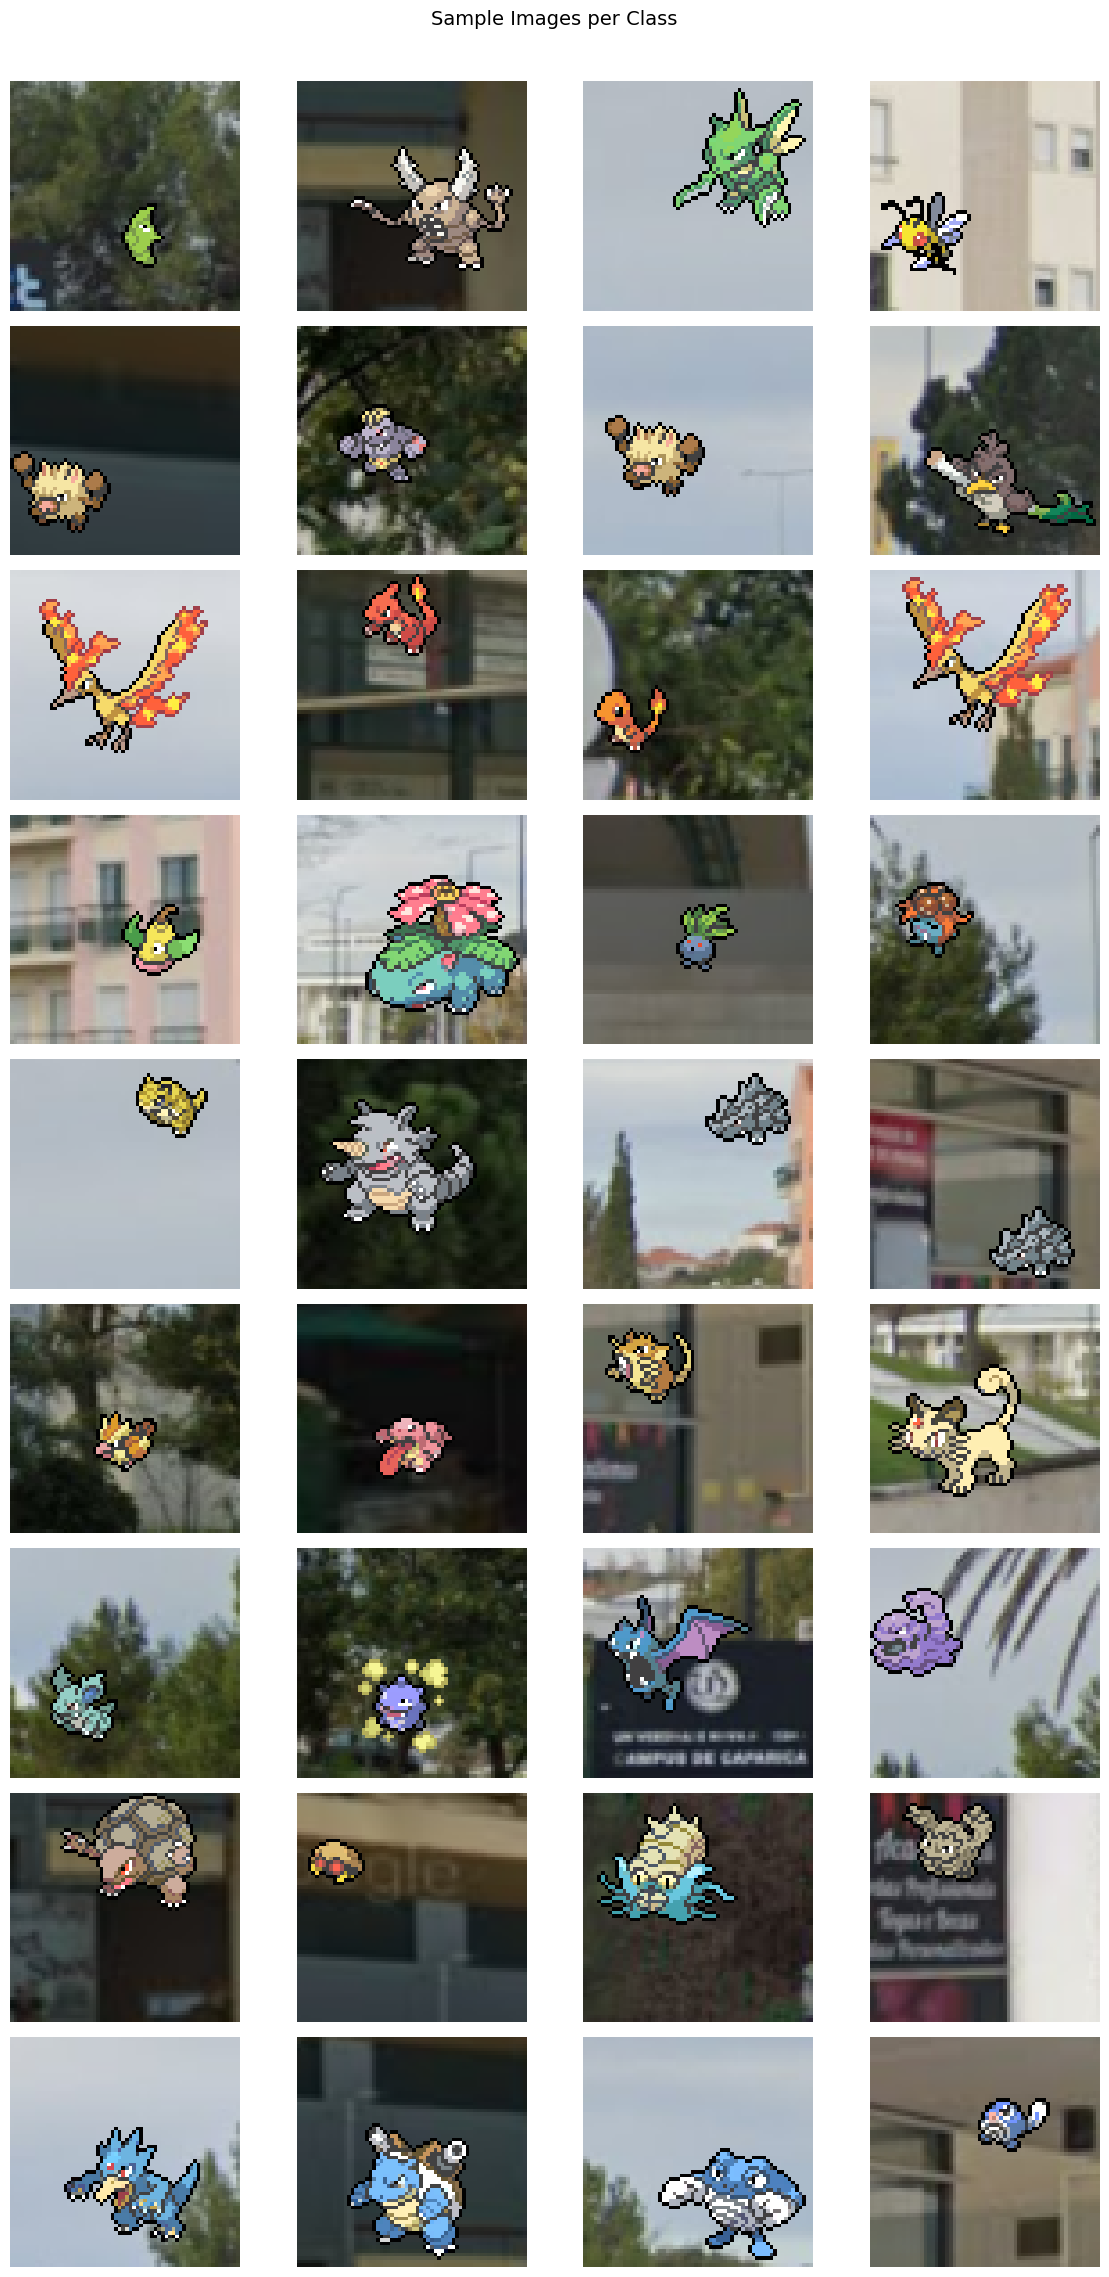

Image width  — min: 64, max: 64, mean: 64
Image height — min: 64, max: 64, mean: 64


In [5]:
# Sample images per class visualisation
classes = sorted(df['label'].unique())
n_classes = len(classes)

fig, axes = plt.subplots(n_classes, 4, figsize=(12, n_classes * 2.5))
fig.suptitle("Sample Images per Class", fontsize=14, y=1.01)

for row, cls in enumerate(classes):
    sample_ids = df[df['label'] == cls]['Id'].sample(min(4, (df['label'] == cls).sum()), random_state=SEED).tolist()
    for col, img_id in enumerate(sample_ids):
        img_path = os.path.join(TRAIN_DIR, f"{img_id}.png")
        try:
            img = Image.open(img_path).convert("RGB")
            axes[row][col].imshow(img)
        except FileNotFoundError:
            axes[row][col].text(0.5, 0.5, "Not found", ha='center', va='center')
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(cls, fontsize=11, rotation=0, labelpad=60, va='center')

plt.tight_layout()
plt.show()

# image sizes
sizes = []
for img_id in df['Id'].sample(200, random_state=SEED):
    img_path = os.path.join(TRAIN_DIR, f"{img_id}.png")
    try:
        w, h = Image.open(img_path).size
        sizes.append((w, h))
    except FileNotFoundError:
        pass

widths, heights = zip(*sizes)
print(f"Image width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Image height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")

The images vary a lot in size and aspect ratio, so resizing to a fixed resolution is necessary before feeding them to any model. More importantly, looking at the samples above it's clear that the real-world backgrounds are the main challenge — the Pokemon themselves often take up a relatively small portion of the image, and the background can dominate the colour and texture signal. This makes types like Normal and Water especially hard since their Pokemon have no strong visual identity compared to e.g. Fire or Grass.

## 2. Dataset & DataLoader

In [ ]:
# Hyperparameters
IMG_SIZE    = 32
N_BINS      = 16      # colour histogram bins per channel (6ch x 16 = 96 dims)
BATCH_SIZE  = 64
VAL_RATIO   = 0.15
N_WORKERS   = 0
LR          = 3e-4
MAX_EPOCHS  = 150
PATIENCE    = 20
DROPOUT     = 0.4
FOCAL_GAMMA = 2.0

RUN_NAME = f"mlp_hog_hist_lr{LR}_bs{BATCH_SIZE}"
RUN_DIR  = os.path.join(os.path.dirname(BASE_DIR), "submissions", RUN_NAME)
os.makedirs(RUN_DIR, exist_ok=True)
CKPT_PATH       = os.path.join(RUN_DIR, "best_model.pth")
SUBMISSION_PATH = os.path.join(RUN_DIR, "submission.csv")
print(f"Run folder: {RUN_DIR}")

# label encoding
le = LabelEncoder()
df['label_idx'] = le.fit_transform(df['label'])
NUM_CLASSES = len(le.classes_)
print(f"Number of classes: {NUM_CLASSES}")
print(f"Class mapping: {dict(enumerate(le.classes_))}")

# stratified train/val split
train_df, val_df = train_test_split(
    df, test_size=VAL_RATIO, stratify=df['label_idx'], random_state=SEED
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
print(f"\nTrain samples: {len(train_df)}  |  Val samples: {len(val_df)}")

In [ ]:
import torch.nn.functional as F
from skimage.feature import hog as sk_hog

# feature extraction: HOG + colour histograms
# HOG on 32x32 (8x8 cells, 2x2 blocks, 9 orientations) -> 324 dims
# colour histograms RGB+HSV (16 bins each) -> 96 dims
# total: 420 dims

def extract_features(img_pil: Image.Image, img_size: int = IMG_SIZE,
                     n_bins: int = N_BINS) -> np.ndarray:
    img = img_pil.convert("RGB").resize((img_size, img_size))
    arr = np.array(img, dtype=np.float32) / 255.0   # (H,W,3) float32 [0,1]

    # HOG on grayscale
    gray = (0.299 * arr[:, :, 0] + 0.587 * arr[:, :, 1]
            + 0.114 * arr[:, :, 2]).astype(np.float32)
    hog_feats = sk_hog(gray, orientations=9, pixels_per_cell=(8, 8),
                       cells_per_block=(2, 2), feature_vector=True,
                       visualize=False).astype(np.float32)

    # RGB colour histograms
    rgb_feats = []
    for ch in range(3):
        hist, _ = np.histogram(arr[:, :, ch], bins=n_bins, range=(0.0, 1.0))
        hist = hist.astype(np.float32)
        hist /= hist.sum() + np.float32(1e-8)
        rgb_feats.append(hist)

    # HSV colour histograms
    r, g, b   = arr[:, :, 0], arr[:, :, 1], arr[:, :, 2]
    cmax      = np.maximum.reduce([r, g, b])
    cmin      = np.minimum.reduce([r, g, b])
    delta     = cmax - cmin + np.float32(1e-8)

    h = np.zeros_like(r)
    mask = cmax == r; h[mask] = ((g[mask] - b[mask]) / delta[mask]) % 6
    mask = cmax == g; h[mask] = (b[mask] - r[mask]) / delta[mask] + 2
    mask = cmax == b; h[mask] = (r[mask] - g[mask]) / delta[mask] + 4
    h = (h / np.float32(6.0)) % np.float32(1.0)
    s = np.where(cmax > np.float32(1e-8),
                 (cmax - cmin) / (cmax + np.float32(1e-8)), np.float32(0.0))
    v = cmax

    hsv_feats = []
    for channel in [h, s, v]:
        hist, _ = np.histogram(channel.ravel(), bins=n_bins, range=(0.0, 1.0))
        hist = hist.astype(np.float32)
        hist /= hist.sum() + np.float32(1e-8)
        hsv_feats.append(hist)

    return np.concatenate([hog_feats] + rgb_feats + hsv_feats).astype(np.float32)


# check feature vector size
_dummy = extract_features(Image.new("RGB", (IMG_SIZE, IMG_SIZE)))
INPUT_DIM = len(_dummy)
print(f"Feature vector size: {INPUT_DIM}  (HOG={len(_dummy)-6*N_BINS} + colour_hist={6*N_BINS})")


class PokemonDataset(Dataset):
    def __init__(self, dataframe, img_dir, augment=False):
        self.df      = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.augment = augment
        self.aug_tf  = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomHorizontalFlip(),
            # no ColorJitter here - it would corrupt the colour histograms
        ])
        self.plain_tf = transforms.Resize((IMG_SIZE, IMG_SIZE))

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        img  = Image.open(
            os.path.join(self.img_dir, f"{row['Id']}.png")).convert("RGB")
        img  = self.aug_tf(img) if self.augment else self.plain_tf(img)
        feat = torch.from_numpy(extract_features(img))
        return feat, int(row['label_idx'])


class PokemonTestDataset(Dataset):
    def __init__(self, img_dir):
        self.img_dir = img_dir
        self.img_ids = [f.replace(".png", "")
                        for f in os.listdir(img_dir) if f.endswith(".png")]
        self.tf = transforms.Resize((IMG_SIZE, IMG_SIZE))

    def __len__(self): return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img    = Image.open(
            os.path.join(self.img_dir, f"{img_id}.png")).convert("RGB")
        feat   = torch.from_numpy(extract_features(self.tf(img)))
        return feat, img_id


# DataLoaders
train_dataset = PokemonDataset(train_df, TRAIN_DIR, augment=True)
val_dataset   = PokemonDataset(val_df,   TRAIN_DIR, augment=False)

class_sample_counts = np.bincount(train_df['label_idx'])
weights_per_class   = 1.0 / class_sample_counts
sample_weights      = weights_per_class[train_df['label_idx'].values]
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(train_dataset), replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=N_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=N_WORKERS, pin_memory=True)

x_sample, _ = next(iter(train_loader))
print(f"Feature shape: {x_sample.shape}  dtype: {x_sample.dtype}")

## 3. MLP Architecture

I tried a few approaches for the input representation. Raw pixels at 96×96 have way too many dimensions (~27k) and the model just overfits. Colour histograms alone (192 dims) completely failed on Normal and Water since those types have no characteristic colour. HOG + colour histograms (420 dims) worked better — HOG captures edges/shapes which helps with colour-neutral types like Normal, Rock, and Fighting.

Architecture:
- Input: 420 (324 HOG + 96 colour histograms)
- FC(420→512) + BN + ReLU + Dropout(0.4)
- FC(512→256) + BN + ReLU + Dropout(0.4)
- FC(256→128) + BN + ReLU + Dropout(0.3)
- FC(128→9)

Loss: Focal Loss (γ=2) + class weights to deal with the imbalance.

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super().__init__()
        self.weight = weight
        self.gamma  = gamma

    def forward(self, inputs, targets):
        ce   = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt   = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


class MLP(nn.Module):
    def __init__(self, input_dim, num_classes, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout * 0.75),

            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)


model = MLP(INPUT_DIM, NUM_CLASSES, dropout=DROPOUT).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {total_params:,}")

class_weights = torch.tensor(
    [1.0 / class_sample_counts[i] for i in range(NUM_CLASSES)], dtype=torch.float
)
class_weights = (class_weights / class_weights.sum() * NUM_CLASSES).to(DEVICE)
criterion = FocalLoss(weight=class_weights, gamma=FOCAL_GAMMA)
print(f"\nClass weights: { {le.classes_[i]: f'{class_weights[i].item():.3f}' for i in range(NUM_CLASSES)} }")

## 4. Training

Using CosineAnnealingLR as the scheduler since it avoids having to tune plateau patience manually. Early stopping tracks validation macro-F1 (not loss) and saves the best checkpoint.

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-5)


def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            logits = model(X)
            total_loss += criterion(logits, y).item() * len(y)
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    avg_loss     = total_loss / len(loader.dataset)
    macro_f1     = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0,
                            labels=list(range(NUM_CLASSES)))
    return avg_loss, macro_f1, per_class_f1


# training loop
history = {"train_loss": [], "val_loss": [], "val_f1": []}
best_val_f1    = -1.0
patience_count = 0

pbar = tqdm(range(1, MAX_EPOCHS + 1), desc="Training", unit="epoch")

for epoch in pbar:
    model.train()
    running_loss = 0.0
    for X, y in train_loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(y)

    train_loss                     = running_loss / len(train_loader.dataset)
    val_loss, val_f1, per_class_f1 = evaluate(model, val_loader)
    current_lr                     = optimizer.param_groups[0]['lr']

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_f1)

    scheduler.step()

    if val_f1 > best_val_f1:
        best_val_f1    = val_f1
        patience_count = 0
        torch.save(model.state_dict(), CKPT_PATH)
    else:
        patience_count += 1

    pbar.set_postfix(
        trn=f"{train_loss:.3f}",
        val=f"{val_loss:.3f}",
        F1=f"{val_f1:.3f}",
        best=f"{best_val_f1:.3f}",
        pat=f"{patience_count}/{PATIENCE}",
        lr=f"{current_lr:.2e}",
    )

    if patience_count >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}. Best val macro-F1: {best_val_f1:.4f}")
        break

print(f"\nBest validation macro-F1: {best_val_f1:.4f}")
print(f"Checkpoint: {CKPT_PATH}")

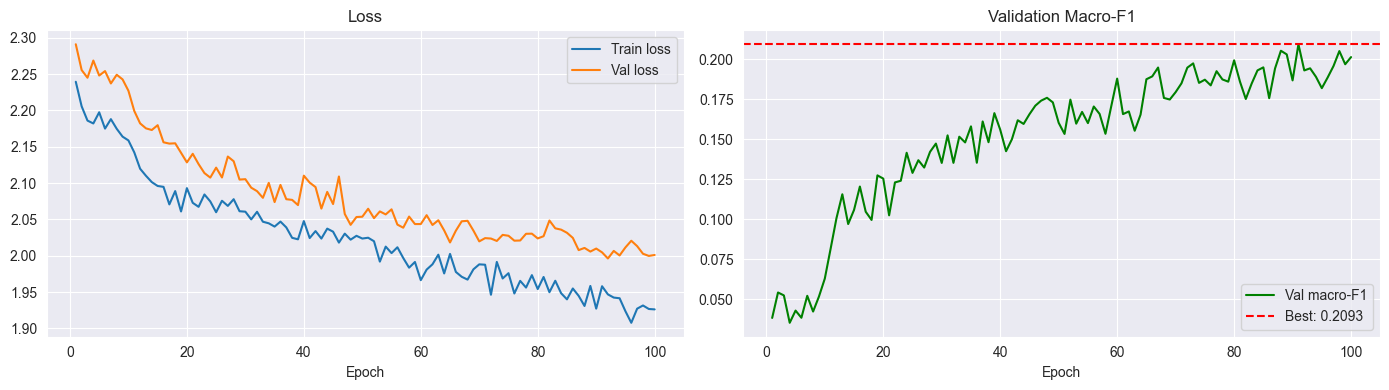

In [46]:
# Training curves
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs_ran, history["train_loss"], label="Train loss")
axes[0].plot(epochs_ran, history["val_loss"],   label="Val loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_ran, history["val_f1"], color="green", label="Val macro-F1")
axes[1].axhline(best_val_f1, color="red", linestyle="--", label=f"Best: {best_val_f1:.4f}")
axes[1].set_title("Validation Macro-F1")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Training stopped early due to patience running out. The validation loss follows the training loss reasonably well with no major divergence, so overfitting isn't the main problem here — the model just plateaus at a low macro-F1. The macro-F1 curve shows some initial improvement but then stalls, suggesting the HOG + histogram features don't have enough discriminative power to go much further.

## 5. Evaluation

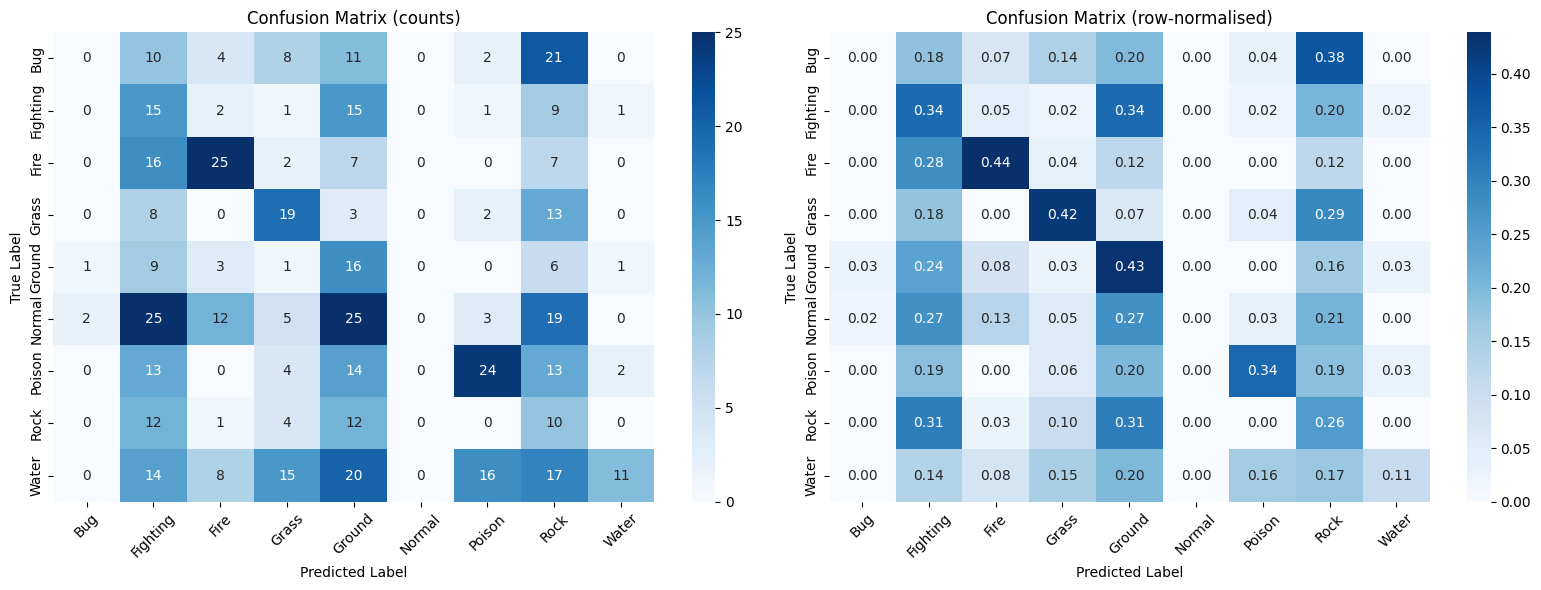

In [47]:
# Load best checkpoint
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

# Full evaluation on validation set
all_preds, all_labels = [], []
with torch.no_grad():
    for X, y in val_loader:
        X = X.to(DEVICE)
        preds = model(X).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

class_names = list(le.classes_)

print("=" * 60)
print("Classification Report (Validation Set)")
print("=" * 60)
print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
print(f"Final Val Macro-F1: {macro_f1:.4f}")

The macro-F1 of 0.21 reflects a model that works reasonably for a couple of classes but completely fails on others. Fire (0.46) and Poison (0.40) are the best performers — both have fairly distinct colour profiles. Bug scored 1.00 precision but 0.02 recall, meaning it was almost never predicted, and when it was it happened to be correct. Normal got 0% on both precision and recall — the model never predicted it once. Water is similar: precision of 0.83 but only 0.15 recall, so the model almost never guesses Water even though it's the most frequent class. Ground has the opposite problem — high recall (0.41) but very low precision (0.11), meaning the model over-predicts it and a lot of other classes get misclassified as Ground.

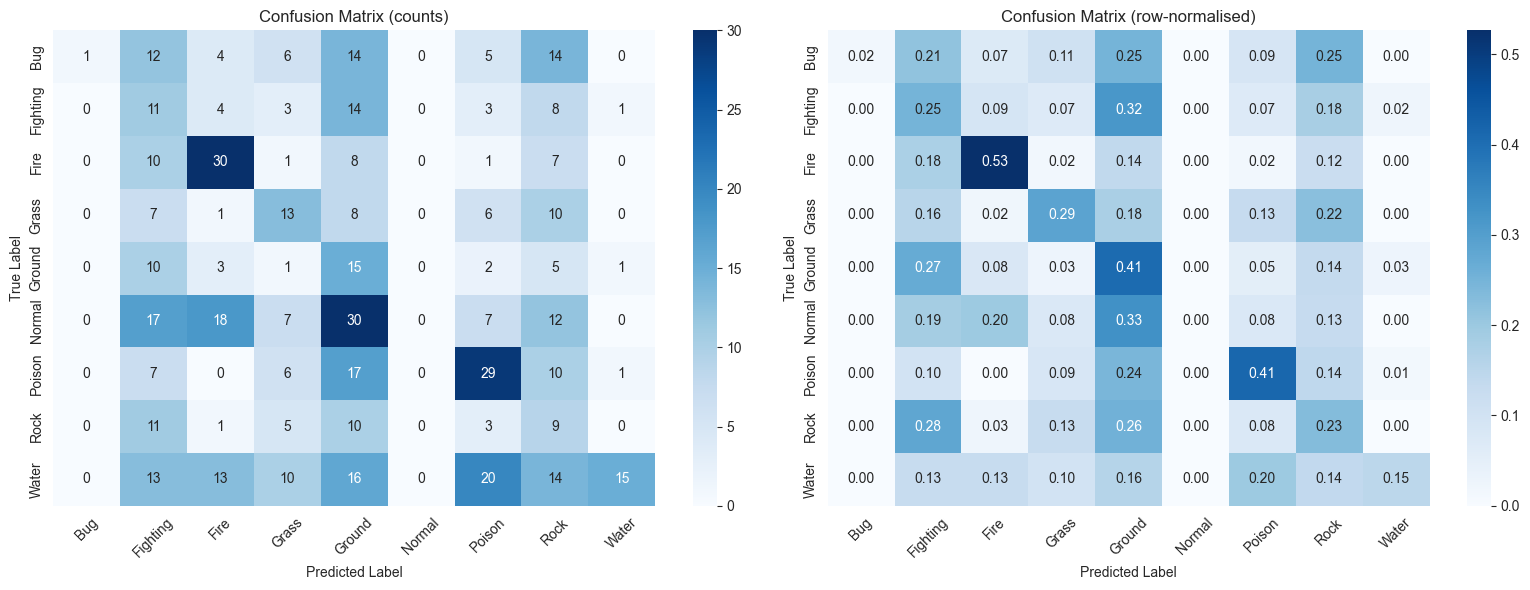

In [48]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title("Confusion Matrix (counts)")
axes[0].set_ylabel("True Label")
axes[0].set_xlabel("Predicted Label")
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title("Confusion Matrix (row-normalised)")
axes[1].set_ylabel("True Label")
axes[1].set_xlabel("Predicted Label")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The normalised confusion matrix makes the per-class failures more visible. Normal samples are spread across almost every other class — the model has no idea what to do with them. Bug and Water are similarly scattered. Ground and Fighting act as "catch-all" buckets where many classes end up. Fire and Poison have the darkest diagonal entries, confirming they're the most reliably classified. Overall this shows the MLP can only distinguish classes with a clear colour or edge signature — anything with ambiguous or background-dominated features gets absorbed by the majority-recall classes.

## 6. Inference on Test Set & Submission

In [ ]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

# test-time augmentation - average a few flips/rotations to reduce variance
tta_aug_fns = [
    None,
    lambda img: img.transpose(Image.FLIP_LEFT_RIGHT),
    lambda img: img.rotate(10),
    lambda img: img.rotate(-10),
]

plain_tf = transforms.Resize((IMG_SIZE, IMG_SIZE))
test_dataset = PokemonTestDataset(TEST_DIR)
test_ids, test_preds = [], []

with torch.no_grad():
    for _, img_id in tqdm(DataLoader(test_dataset, batch_size=1, shuffle=False,
                                     num_workers=N_WORKERS),
                          desc="TTA inference"):
        img_orig = Image.open(
            os.path.join(TEST_DIR, f"{img_id[0]}.png")).convert("RGB")

        logits_sum = torch.zeros(1, NUM_CLASSES, device=DEVICE)
        for aug_fn in tta_aug_fns:
            img  = plain_tf(aug_fn(img_orig) if aug_fn else img_orig)
            feat = torch.from_numpy(extract_features(img)).unsqueeze(0).to(DEVICE)
            logits_sum += model(feat)

        test_ids.append(img_id[0])
        test_preds.append(logits_sum.argmax(dim=1).item())

pred_labels = le.inverse_transform(test_preds)
submission  = pd.DataFrame({"Id": test_ids, "label": pred_labels})
submission.to_csv(SUBMISSION_PATH, index=False)
print(f"Submission: {SUBMISSION_PATH}  ({len(submission)} predictions)")
print("\nPrediction distribution:")
print(submission['label'].value_counts().to_string())
submission.head(10)

## 7. Conclusions

### What we've tried

Started with raw pixels (96×96 → 27k dims) which just overfit immediately. Switched to colour histograms only (192 dims) but that got 0% F1 on both Normal and Water, the model had no shape information, just colour distributions. The current version uses HOG + colour histograms (420 dims total) which at least gives the model some edge/texture information alongside colour.

### Why Normal and Water were hard

Normal doesn't have a consistent colour or shape, they can look like almost anything. Water Pokemon tend to be blue but backgrounds (sky, walls, shadows) are also often blue-toned, so the histograms get confused. Without spatial context, distinguishing these is very difficult.

### MLP limitations

Since there are no convolutional layers, the MLP treats each input dimension independently after feature extraction, there's no way to capture local spatial patterns. This is the core reason a CNN should do significantly better in Stage 2. The MLP here is just a baseline.